# **001 First steps: ✅**

In [ ]:
!pip install bertopic gensim pyLDAvis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import os

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.8/158.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 30.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 11.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.7/224.7 kB 28.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 89.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 8.6 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  U

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Read the data
file_path = '/content/drive/MyDrive/SMWA Project/Africa/un-general-debates.csv'

df = pd.read_csv(file_path)

print(df.head())


   session  year country                                               text
0       44  1989     MDV  ﻿It is indeed a pleasure for me and the member...
1       44  1989     FIN  ﻿\nMay I begin by congratulating you. Sir, on ...
2       44  1989     NER  ﻿\nMr. President, it is a particular pleasure ...
3       44  1989     URY  ﻿\nDuring the debate at the fortieth session o...
4       44  1989     ZWE  ﻿I should like at the outset to express my del...


In [ ]:
total_observations = df.shape[0]
print("Total observations:", total_observations)


Total observations: 7507


In [ ]:
missing_values = df.isnull()

#Counting the missing values in each column
missing_count = missing_values.sum()

#calculating the proportion of missing values in each column
missing_proportion = missing_values.mean()

#display the missing count and proportion
missing_info = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Proportion': missing_proportion
})

print("Missing values information:")
print(missing_info)


Missing values information:
         Missing Count  Missing Proportion
session              0                 0.0
year                 0                 0.0
country              0                 0.0
text                 0                 0.0


In [ ]:
summary_y = df['year'].describe()
print(summary_y)

count    7507.000000
mean     1994.610763
std        12.892155
min      1970.000000
25%      1984.000000
50%      1996.000000
75%      2006.000000
max      2015.000000
Name: year, dtype: float64


In [ ]:
country = df['country'].unique()
print(country)

['MDV' 'FIN' 'NER' 'URY' 'ZWE' 'PHL' 'SDN' 'RUS' 'CHN' 'ESP' 'SUR' 'ARG'
 'SLV' 'MYS' 'NPL' 'PRT' 'COL' 'BLR' 'MAR' 'LCA' 'EGY' 'MEX' 'BEL' 'BRN'
 'RWA' 'CAN' 'ALB' 'GRC' 'KNA' 'GUY' 'LBR' 'ATG' 'MOZ' 'JPN' 'YDYE' 'GAB'
 'BGD' 'SWE' 'TUR' 'TCD' 'SYR' 'CMR' 'JAM' 'LUX' 'ITA' 'AGO' 'CRI' 'CSK'
 'BFA' 'MNG' 'BHR' 'HTI' 'OMN' 'CIV' 'TGO' 'CYP' 'MUS' 'MMR' 'ARE' 'GTM'
 'GRD' 'LBY' 'LKA' 'TZA' 'SGP' 'NOR' 'LAO' 'ISL' 'AFG' 'CHL' 'DMA' 'UKR'
 'KEN' 'BLZ' 'FRA' 'MLI' 'VCT' 'VEN' 'MLT' 'GHA' 'GIN' 'GBR' 'ISR' 'YUG'
 'BRB' 'IRQ' 'HUN' 'AUT' 'POL' 'GNB' 'BWA' 'MRT' 'SWZ' 'DNK' 'DOM' 'MDG'
 'NIC' 'BDI' 'CUB' 'IRN' 'PAK' 'SEN' 'BGR' 'YEM' 'STP' 'NLD' 'VUT' 'BOL'
 'PNG' 'SLB' 'DEU' 'ROU' 'KHM' 'TUN' 'BRA' 'IND' 'IDN' 'AUS' 'COD' 'HND'
 'GNQ' 'FJI' 'IRL' 'DZA' 'USA' 'LSO' 'GMB' 'PER' 'DDR' 'THA' 'JOR' 'COG'
 'NGA' 'ECU' 'SAU' 'QAT' 'SYC' 'ETH' 'TTO' 'PRY' 'VNM' 'NZL' 'PAN' 'MWI'
 'DJI' 'BEN' 'SOM' 'ZMB' 'CPV' 'BHS' 'KWT' 'UGA' 'COM' 'ZAF' 'LBN' 'SLE'
 'KOR' 'BIH' 'TON' 'EU' 'HRV' 'NRU' 'TUV' 'NAM' 'S

In [ ]:
#Define a function to map country codes to continents
def map_continent(country_code):
    return country_to_continent.get(country_code)

#Define a dictionary mapping countries to continents, I did all the countires just in case i want to do an analysis on another continent or country!
country_to_continent = {
    'IRN': 'Asia', 'IRQ': 'Asia', 'ALB': 'Europe', 'NLD': 'Europe', 'ECU': 'South America', 'JPN': 'Asia',
    'CUB': 'North America', 'TUR': 'Asia', 'SYR': 'Asia', 'AUT': 'Europe', 'ITA': 'Europe', 'ISR': 'Asia',
    'RWA': 'Africa', 'GBR': 'Europe', 'GHA': 'Africa', 'VEN': 'South America', 'FRA': 'Europe', 'NZL': 'Oceania',
    'UKR': 'Europe', 'GTM': 'North America', 'ISL': 'Europe', 'LKA': 'Asia', 'CAN': 'North America', 'PAK': 'Asia',
    'BOL': 'South America', 'COL': 'South America', 'USA': 'North America', 'URY': 'South America', 'DZA': 'Africa',
    'PHL': 'Asia', 'SDN': 'Africa', 'AUS': 'Oceania', 'IDN': 'Asia', 'ARG': 'South America', 'SLV': 'North America',
    'BEL': 'Europe', 'BRA': 'South America', 'TUN': 'Africa', 'IND': 'Asia', 'PER': 'South America', 'MEX': 'North America',
    'BLR': 'Europe', 'COG': 'Africa', 'MAR': 'Africa', 'IRL': 'Europe', 'LAO': 'Asia', 'NGA': 'Africa', 'AFG': 'Asia',
    'CHL': 'South America', 'ROU': 'Europe', 'KEN': 'Africa', 'YEM': 'Asia', 'MRT': 'Africa', 'PRY': 'South America',
    'QAT': 'Asia', 'BGR': 'Europe', 'GIN': 'Africa', 'SGP': 'Asia', 'FIN': 'Europe', 'HUN': 'Europe', 'BDI': 'Africa',
    'POL': 'Europe', 'ETH': 'Africa', 'JOR': 'Asia', 'TZA': 'Africa', 'NPL': 'Asia', 'JAM': 'North America',
    'CRI': 'North America', 'BFA': 'Africa', 'MNG': 'Asia', 'KWT': 'Asia', 'LBR': 'Africa', 'MYS': 'Asia',
    'ESP': 'Europe', 'SLE': 'Africa', 'GRC': 'Europe', 'TGO': 'Africa', 'CYP': 'Europe', 'MUS': 'Africa',
    'CHN': 'Asia', 'MMR': 'Asia', 'RUS': 'Europe', 'LBY': 'Africa', 'SEN': 'Africa', 'NOR': 'Europe', 'EGY': 'Africa',
    'PRT': 'Europe', 'SWE': 'Europe', 'COD': 'Africa', 'HND': 'North America', 'NER': 'Africa', 'DOM': 'North America',
    'NIC': 'North America', 'THA': 'Asia', 'ARE': 'Asia', 'BEN': 'Africa', 'HTI': 'North America', 'BHR': 'Asia',
    'TCD': 'Africa', 'BRB': 'North America', 'FJI': 'Oceania', 'MLI': 'Africa', 'OMN': 'Asia', 'DNK': 'Europe',
    'DEU': 'Europe', 'LUX': 'Europe', 'MLT': 'Europe', 'CAF': 'Africa', 'MDG': 'Africa', 'PAN': 'North America',
    'BGD': 'Asia', 'GAB': 'Africa', 'UGA': 'Africa', 'LBN': 'Asia', 'GUY': 'South America', 'KHM': 'Asia',
    'CMR': 'Africa', 'BTN': 'Asia', 'ZMB': 'Africa', 'LSO': 'Africa', 'SUR': 'South America', 'BWA': 'Africa',
    'PNG': 'Oceania', 'GRD': 'North America', 'MOZ': 'Africa', 'COM': 'Africa', 'TTO': 'North America',
    'MDV': 'Asia', 'GNQ': 'Africa', 'GNB': 'Africa', 'AGO': 'Africa', 'GMB': 'Africa', 'VNM': 'Asia', 'CPV': 'Africa',
    'BHS': 'North America', 'YUG': 'Europe', 'SWZ': 'Africa', 'MWI': 'Africa', 'SOM': 'Africa', 'ZWE': 'Africa',
    'SAU': 'Asia', 'VCT': 'North America', 'BLZ': 'North America', 'SLB': 'Oceania', 'CIV': 'Africa',
    'ATG': 'North America', 'LCA': 'North America', 'BRN': 'Asia', 'WSM': 'Oceania', 'STP': 'Africa',
    'KNA': 'North America', 'VUT': 'Oceania', 'DMA': 'North America', 'DJI': 'Africa', 'ZAF': 'Africa',
    'SYC': 'Africa', 'NAM': 'Africa', 'LIE': 'Europe', 'LTU': 'Europe', 'KOR': 'Asia', 'PRK': 'Asia',
    'LVA': 'Europe', 'EST': 'Europe', 'TJK': 'Asia', 'MHL': 'Oceania', 'KAZ': 'Asia', 'MDA': 'Europe',
    'AZE': 'Asia', 'ARM': 'Asia', 'KGZ': 'Asia', 'SVN': 'Europe', 'BIH': 'Europe', 'FSM': 'Oceania',
    'SMR': 'Europe', 'HRV': 'Europe', 'SVK': 'Europe', 'GEO': 'Asia', 'MCO': 'Europe', 'MKD': 'Europe',
    'ERI': 'Africa', 'CZE': 'Europe', 'AND': 'Europe', 'UZB': 'Asia', 'TKM': 'Asia', 'YDYE': 'Asia',
    'PLW': 'Oceania', 'DDR': 'Europe', 'PSE': 'Asia', 'NRU': 'Oceania', 'TON': 'Oceania', 'TUV': 'Oceania',
    'CHE': 'Europe', 'KIR': 'Oceania', 'VAT': 'Europe', 'TLS': 'Asia', 'MNE': 'Europe', 'SSD': 'Africa', 'EU': 'Europe', 'CSK': 'Europe'
}

#add a new column Continent
df['Continent'] = df['country'].apply(map_continent)

df.to_csv('/content/drive/MyDrive/SMWA Project/Africa/mapped data.csv', index=False)


In [ ]:
import nltk
nltk.download('punkt')

import nltk
nltk.download('wordnet')

import nltk
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Filter statments from Africa
africa_df = df[df['Continent'] == 'Africa']

# Clean and tokenize the text
def clean_text(text):
    # Remove Unicode BOM and non-visible characters
    text = text.encode('ascii', errors='ignore').decode('ascii')
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Tokenize
    return word_tokenize(text)

africa_df['tokens'] = africa_df['text'].apply(clean_text)

# Remove stop words and filter out empty tokens
stop_words = stopwords.words('english')
africa_df['filtered_tokens'] = africa_df['tokens'].apply(lambda tokens: [token for token in tokens if token.lower() not in stop_words and token.strip() != ''])

# Lemmatization
lemmatizer = WordNetLemmatizer()
africa_df['lemmatized_tokens'] = africa_df['filtered_tokens'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

# Create a new DataFrame with the processed data
processed_df0 = africa_df[['session', 'year', 'country', 'Continent', 'text', 'lemmatized_tokens']]
processed_df0.columns = ['session', 'year', 'country', 'Continent', 'text', 'processed_text']

def clean_illegal_chars(df):
    # Define the set of illegal characters, I had an error here
    illegal_chars = re.compile(r'[\000-\010]|[\013-\014]|[\016-\037]')

    # Function to clean individual cell
    def clean_cell(value):
        if isinstance(value, str):
            return illegal_chars.sub('', value)
        return value

    # Apply the cleaning function to the entire DataFrame
    return df.applymap(clean_cell)

# Clean illegal characters from the DataFrame
processed_df = clean_illegal_chars(processed_df0)

# Save the processed data to an Excel file
output_file_path = '/content/drive/MyDrive/SMWA Project/Africa/processed_data.xlsx'
processed_df.to_excel(output_file_path, index=False)

print(f"Processed data saved to '{output_file_path}'")


<ipython-input-10-3b52d3489ccf>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  africa_df['tokens'] = africa_df['text'].apply(clean_text)
<ipython-input-10-3b52d3489ccf>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  africa_df['filtered_tokens'] = africa_df['tokens'].apply(lambda tokens: [token for token in tokens if token.lower() not in stop_words and token.strip() != ''])
<ipython-input-10-3b52d3489ccf>:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

Processed data saved to '/content/drive/MyDrive/SMWA Project/Africa/processed_data.xlsx'


In [ ]:
print(processed_df.head())

    session  year country Continent  \
2        44  1989     NER    Africa   
4        44  1989     ZWE    Africa   
6        44  1989     SDN    Africa   
18       44  1989     MAR    Africa   
20       44  1989     EGY    Africa   

                                                 text  \
2   ﻿\nMr. President, it is a particular pleasure ...   
4   ﻿I should like at the outset to express my del...   
6   ﻿It gives me great pleasure to congratulate Am...   
18  ﻿ At the outset. Sit, let me, on behalf of the...   
20  ﻿\nIt gives me pleasure at the beginning of my...   

                                       processed_text  
2   [Mr, President, particular, pleasure, behalf, ...  
4   [like, outset, express, delegation, satisfacti...  
6   [give, great, pleasure, congratulate, Ambassad...  
18  [outset, Sit, let, behalf, delegation, Kingdom...  
20  [give, pleasure, beginning, address, fortyfour...  


In [ ]:

total_observations = processed_df.shape[0]
print("Total observations:", total_observations)


Total observations: 2159


# **002 EDA: 📊📉**

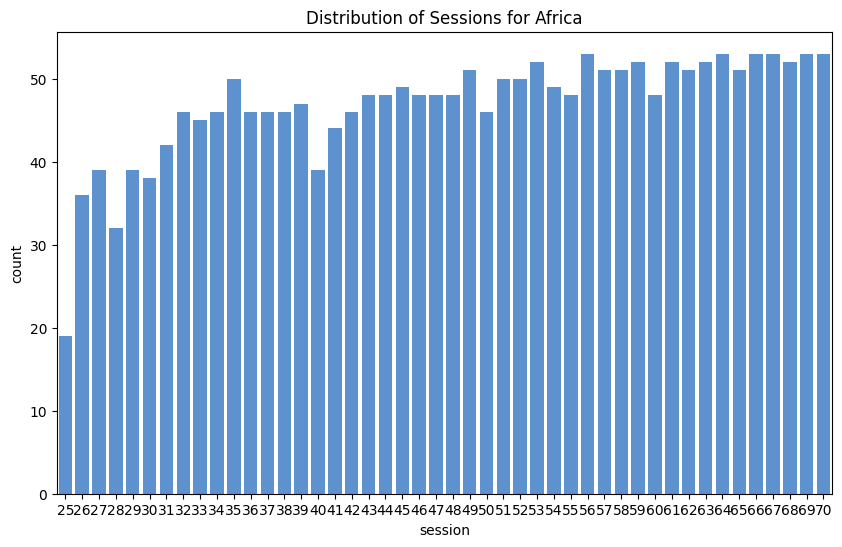

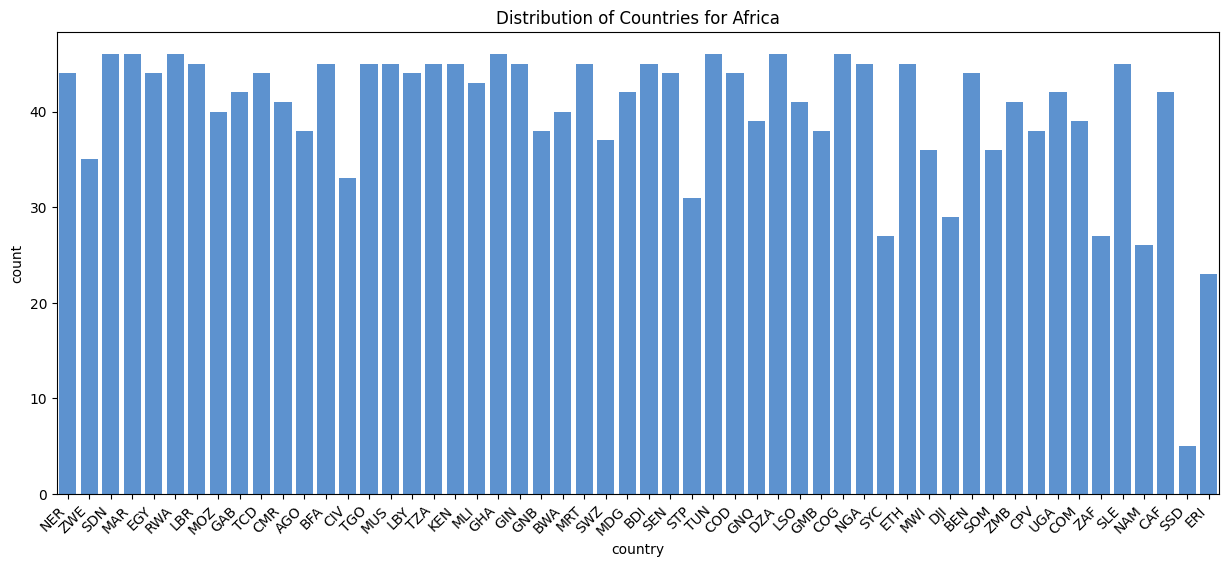

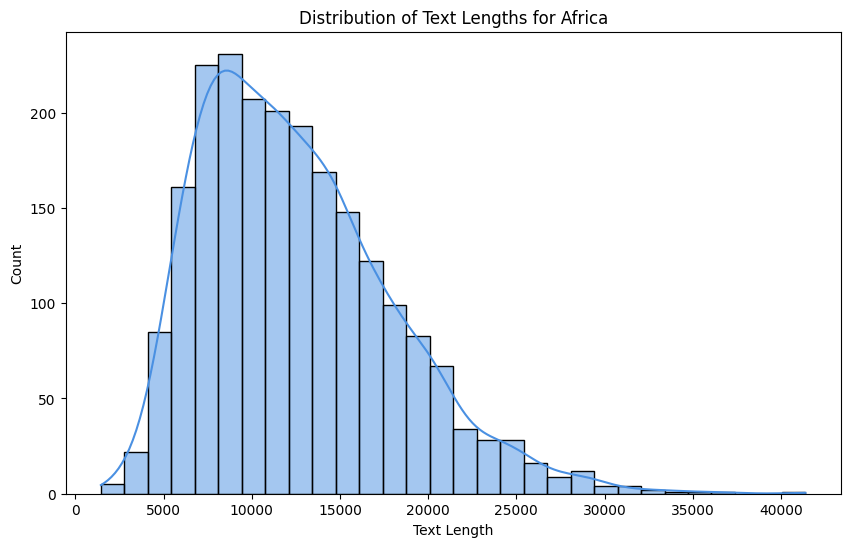

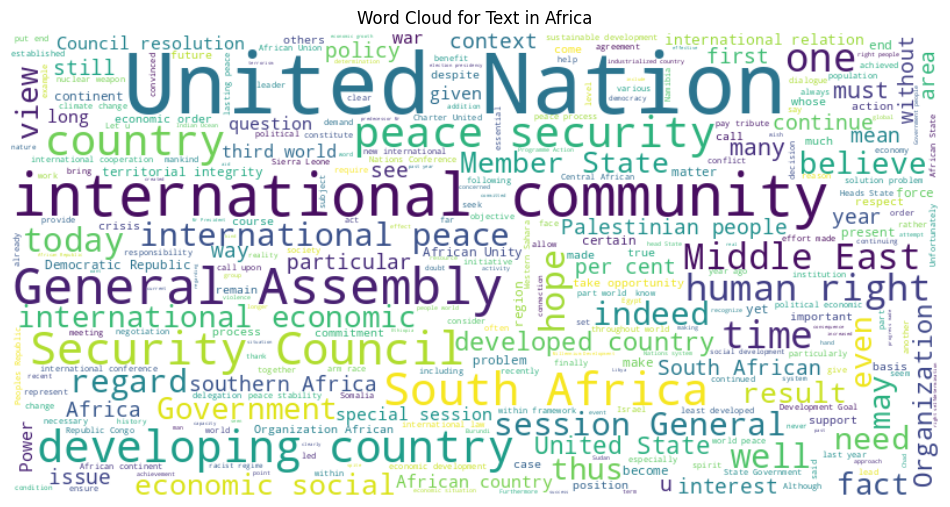

In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
%matplotlib inline

# Directory path where the images will be saved
output_directory = "/content/drive/MyDrive/SMWA Project/Africa/Graphs"

# UN colors
un_palette = ["#4A90E2", "#FFFFFF", "#5BAA52"]

# Set the palette for seaborn plots
sns.set_palette(un_palette)

# Countplot of sessions
plt.figure(figsize=(10, 6))
sns.countplot(x='session', data=processed_df)
plt.title('Distribution of Sessions for Africa')
plt.savefig(os.path.join(output_directory, "sessions_distribution_Africa.png"))
plt.show()
plt.close()

# Countplot of countries
plt.figure(figsize=(15, 6))
sns.countplot(x='country', data=processed_df)
plt.title('Distribution of Countries for Africa')
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(output_directory, "countries_distribution_Africa.png"))
plt.show()
plt.close()

# Distribution of text lengths
processed_df['text_length'] = processed_df['processed_text'].apply(lambda x: len(' '.join(x)))
plt.figure(figsize=(10, 6))
sns.histplot(processed_df['text_length'], bins=30, kde=True)
plt.title('Distribution of Text Lengths for Africa')
plt.xlabel('Text Length')
plt.savefig(os.path.join(output_directory, "text_lengths_distribution_Africa.png"))
plt.show()
plt.close()

# Wordcloud for text
text_combined = ' '.join(processed_df['processed_text'].apply(lambda x: ' '.join(x)))
wordcloud = WordCloud(width=800, height=400, max_words=300, background_color='white').generate(text_combined)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Text in Africa')
plt.savefig(os.path.join(output_directory, "wordcloud_Africa.png"))
plt.show()
plt.close()


# **003 Sentiment Analysis 🟢🔵🔴**

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


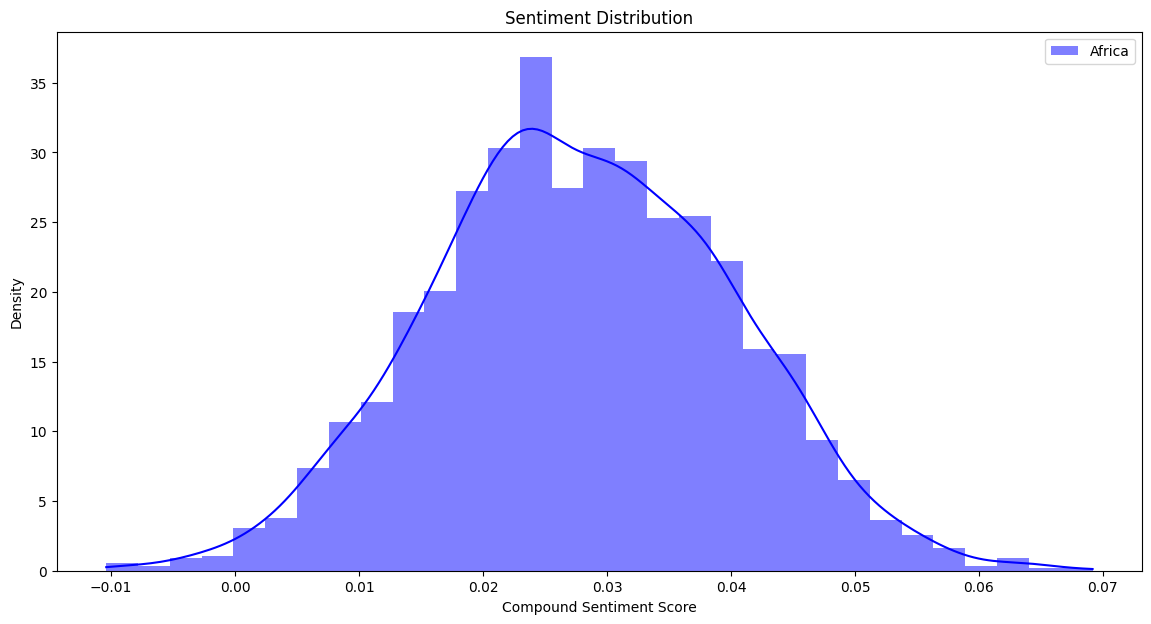

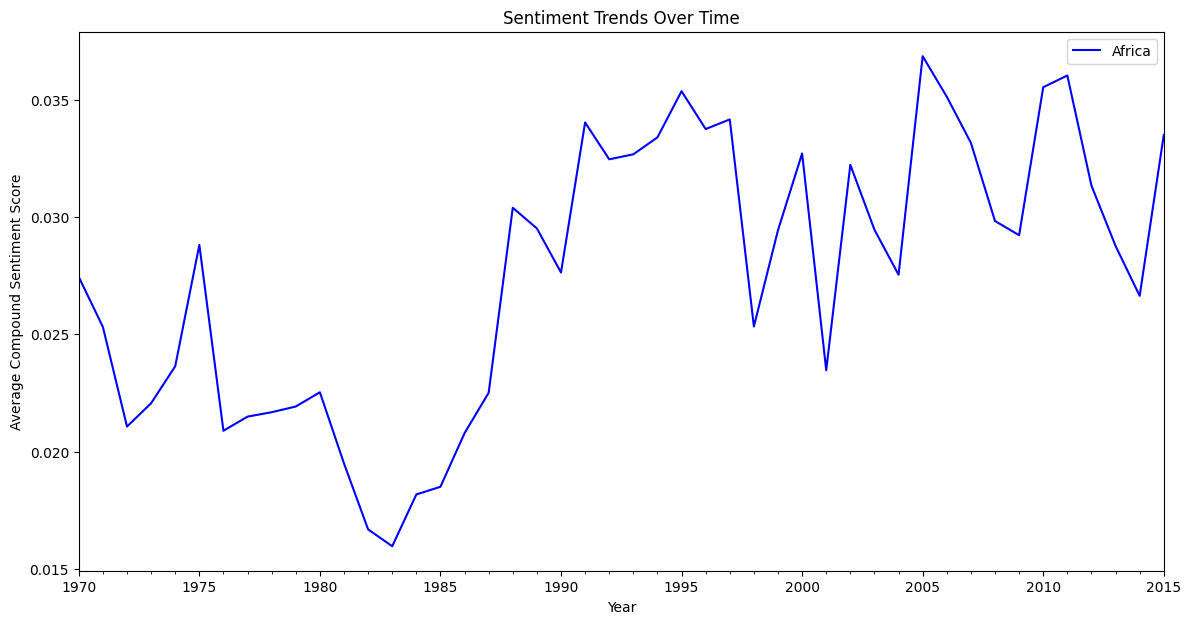

In [ ]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from datetime import datetime
import textwrap
%matplotlib inline

nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('wordnet')

# Initialize VADER sentiment analyzer and WordNet lemmatizer
analyser = SentimentIntensityAnalyzer()
lemmatizer = WordNetLemmatizer()

# Process text into sentences and lemmatize
def to_sentences_lemmas(text_list):
    sentences = []
    for text in text_list:
        sent_list = sent_tokenize(text.lower())
        lemmas = [' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(sentence)]) for sentence in sent_list]
        sentences.extend(lemmas)
    return sentences

# Apply sentence and lemma processing
processed_df['sentences'] = processed_df['processed_text'].apply(to_sentences_lemmas)

# Sentiment analysis function
def sentiment_analysis(sentences):
    scores = [analyser.polarity_scores(sentence) for sentence in sentences]
    return pd.DataFrame(scores).mean().to_dict()

# Apply sentiment analysis
sentiment_scores = processed_df['sentences'].apply(sentiment_analysis)
processed_df = pd.concat([processed_df, sentiment_scores.apply(pd.Series)], axis=1)

# Remove duplicate columns
processed_df = processed_df.loc[:, ~processed_df.columns.duplicated()]

# Function to classify sentiment
def classify_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'positive'
    elif compound_score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply classification
processed_df['sentiment_class'] = processed_df['compound'].apply(classify_sentiment)

# Sentiment distribution
plt.figure(figsize=(14, 7))
sns.histplot(processed_df['compound'], kde=True, color='blue', label='Africa', stat="density", linewidth=0, alpha=0.5)
plt.legend()
plt.title('Sentiment Distribution')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Density')
plt.savefig("/content/drive/MyDrive/SMWA Project/Africa/Graphs/sentiment_distribution.png")
plt.show()

# Sentiment trends over time
processed_df['year'] = pd.to_datetime(processed_df['year'], format='%Y', errors='coerce')
processed_df.set_index('year', inplace=True)

plt.figure(figsize=(14, 7))
processed_df['compound'].resample('Y').mean().plot(label='Africa', color='blue')
plt.legend()
plt.title('Sentiment Trends Over Time')
plt.xlabel('Year')
plt.ylabel('Average Compound Sentiment Score')
plt.savefig("/content/drive/MyDrive/SMWA Project/Africa/Graphs/sentiment_trends_over_time.png")
plt.show()


In [ ]:
#Checking the head of the data
print(processed_df.columns)
print(processed_df.head())  # Display the first few rows to verify the 'compound' column


Index(['session', 'country', 'Continent', 'text', 'processed_text',
       'text_length', 'sentences', 'neg', 'neu', 'pos', 'compound',
       'sentiment_class'],
      dtype='object')
            session country Continent  \
year                                    
1989-01-01       44     NER    Africa   
1989-01-01       44     ZWE    Africa   
1989-01-01       44     SDN    Africa   
1989-01-01       44     MAR    Africa   
1989-01-01       44     EGY    Africa   

                                                         text  \
year                                                            
1989-01-01  ﻿\nMr. President, it is a particular pleasure ...   
1989-01-01  ﻿I should like at the outset to express my del...   
1989-01-01  ﻿It gives me great pleasure to congratulate Am...   
1989-01-01  ﻿ At the outset. Sit, let me, on behalf of the...   
1989-01-01  ﻿\nIt gives me pleasure at the beginning of my...   

                                               processed_text  text_len

In [ ]:
!pip install vaderSentiment

import numpy as np
import pandas as pd
import nltk
from nltk import word_tokenize, sent_tokenize, pos_tag, pos_tag_sents
import re
import gensim
import gensim.corpora as corpora
import gensim.models.ldamodel as ldamodel
import pyLDAvis.gensim
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.probability import FreqDist
from IPython.utils.text import columnize
import warnings
warnings.filterwarnings("ignore")
import textwrap
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

%matplotlib notebook
plt.style.use('seaborn-darkgrid')

df = pd.read_excel('/content/drive/MyDrive/SMWA Project/Africa/processed_data.xlsx')

import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.probability import FreqDist
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('vader_lexicon')
nltk.download('wordnet')

# Assuming df is your DataFrame with text data
df['freq_dist'] = df['text'].apply(FreqDist)

def to_sentences_lemmas(text):
    sentences = sent_tokenize(text.lower())
    lemmatizer = nltk.stem.WordNetLemmatizer()
    lemmas = [[lemmatizer.lemmatize(word) for word in word_tokenize(sentence)]
              for sentence in sentences]
    return lemmas

# List of sentences in which each sentence is itself a list
df['sentences_lemmas'] = df['text'].apply(to_sentences_lemmas)
df['sentences'] = df['text'].str.replace('\n+', ' ').apply(sent_tokenize)
df[['sentences_lemmas', 'sentences']].head()

def summarize(x):
    m = x['freq_dist'].most_common(1)[0][1]  # get the highest count
    scores = [sum([x['freq_dist'][word] / m for word in sentence]
                 ) for sentence in x['sentences_lemmas']]
    indexes = [i for i in range(len(scores))]
    zipped = list(zip(scores, indexes))
    zipped = sorted(zipped, key=lambda x: x[0], reverse=True)
    n = int(len(indexes) / 10)
    # get the index of sentences with n highest scores:
    i = [zipped[item][1] for item in range(n)]
    return [x['sentences'][index] for index in i]

df['summary'] = df.apply(summarize, axis=1)

# Define the function to get strongest sentiments
def strongest_sentiments(text):
    analyser = SentimentIntensityAnalyzer()
    scores = [analyser.polarity_scores(sentence)['compound'] for sentence in text]
    indexes = [i for i in range(len(scores))]
    zipped = list(zip(scores, indexes))
    zipped_positive = sorted(zipped, key=lambda x: x[0], reverse=True)
    zipped_negative = sorted(zipped, key=lambda x: x[0], reverse=False)
    n = int(len(indexes) / 250)
    # get the index of sentences with n highest scores:
    most_positive = [zipped_positive[item][1] for item in range(n)]
    most_negative = [zipped_negative[item][1] for item in range(n)]
    return [text[index] for index in most_positive], [text[index] for index in most_negative]

# Filter sentences for Africa
africa_sentences = df['sentences'].sum()

# Get strongest sentiments for Africa
positive_africa, negative_africa = strongest_sentiments(africa_sentences)

# Create text for word clouds
text_positive_africa = ' '.join(positive_africa)
text_negative_africa = ' '.join(negative_africa)

# Function to generate and save word clouds
def generate_wordcloud(text, title, save_path, background_color='white'):
    wordcloud = WordCloud(background_color=background_color, max_words=2000).generate(text)
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.savefig(save_path)
    plt.show()
    plt.close()

# Save the word clouds
save_dir = '/content/drive/MyDrive/SMWA Project/Africa/Graphs/'

# Africa
generate_wordcloud(text_positive_africa, 'Positive Sentiments - Africa', save_dir + 'positive_africa.png')
generate_wordcloud(text_negative_africa, 'Negative Sentiments - Africa', save_dir + 'negative_africa.png', background_color='black')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.7 MB/s eta 0:00:00


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **004 LDA 🌟**

In [ ]:
import pandas as pd
import gensim.corpora as corpora
from gensim.models import ldamodel
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import re

def find_topics(no_above, no_below, num_topics, data_frame):
    texts = data_frame['processed_text'].tolist()
    stop_words = set(stopwords.words('english'))

    texts = [[word for word in simple_preprocess(str(doc))
              if word not in stop_words and not word.isdigit() and len(word) > 3]
             for doc in texts]

    # Create a dictionary and filter extremes
    id2word = corpora.Dictionary(texts)
    id2word.filter_extremes(no_above=no_above, no_below=no_below)

    # Create corpus
    corpus = [id2word.doc2bow(text) for text in texts]

    # Train LDA model
    lda = ldamodel.LdaModel(corpus, num_topics=num_topics, passes=50, random_state=0, id2word=id2word)
    return lda, corpus, id2word

# Number of topics for the LDA
num_topics = 10

# Run LDA
lda_africa, corpus_africa, id2word_africa = find_topics(0.3, 10, num_topics, processed_df)

# Enabling the visualization of topics
pyLDAvis.enable_notebook()
vis_africa = gensimvis.prepare(lda_africa, corpus_africa, id2word_africa)
vis_africa


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4     -0.010796  0.009484       1        1  39.432977
3     -0.035351 -0.004310       2        1  27.774426
7     -0.024934 -0.018308       3        1   8.667862
9      0.019648 -0.038211       4        1   5.513277
2     -0.018168 -0.030913       5        1   4.966943
1     -0.053731  0.046503       6        1   4.106661
8     -0.076682  0.107642       7        1   2.850753
6      0.073646 -0.212843       8        1   2.652376
5     -0.147404  0.029629       9        1   2.543818
0      0.273772  0.111327      10        1   1.490906, topic_info=           Term         Freq        Total Category  logprob  loglift
1134   zimbabwe  1397.000000  1397.000000  Default  30.0000  30.0000
3114    somalia  1646.000000  1646.000000  Default  29.0000  29.0000
83         chad  1316.000000  1316.000000  Default  28.0000  28.0000
4246     guinea  1028.000000  1028.000000  Default  27.0000  27.0000
750    colonial  1594.000000  1594.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
933       might    46.560462  1102.897132  Topic10  -5.9358   1.0408
2449   fighting    41.634595   623.974502  Topic10  -6.0476   1.4986
1135    ability    42.886791   858.921415  Topic10  -6.0180   1.2087
5891      smith    39.447484   440.541656  Topic10  -6.1016   1.7928
2859  secretary    39.517353   780.776451  Topic10  -6.0998   1.2222

[740 rows x 6 columns], token_table=      Topic      Freq     Term
term                          
4827      9  0.964157  abidine
1135      1  0.222372  ability
1135      2  0.429609  ability
1135      3  0.119918  ability
1135      4  0.058213  ability
...     ...       ...      ...
1649      6  0.057111     zone
1649      7  0.008290     zone
1649      8  0.006448     zone
1649      9  0.024871     zone
1649     10  0.017502     zone

[2326 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 8, 10, 3, 2, 9, 7, 6, 1])

In [ ]:
import pandas as pd
import gensim.corpora as corpora
from gensim.models import ldamodel
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import re
import matplotlib.pyplot as plt
import numpy as np

# Function to get topic distribution
def get_topic_distribution(lda_model, corpus):
    topic_distribution = [dict(lda_model.get_document_topics(bow)) for bow in corpus]
    topic_df = pd.DataFrame(topic_distribution).fillna(0)
    return topic_df.mean()

# Calculate mean topic distributions for Africa
topic_dist_africa = get_topic_distribution(lda_africa, corpus_africa)

# Verify and order the topics based on the output text
def debug_topic_alignment(topic_dist_africa, lda_model, num_words=10):
    topics = []
    print("Verifying topic distributions:")
    for i in range(len(topic_dist_africa)):
        african_dist = topic_dist_africa[i]
        topic_terms = lda_model.show_topic(i, topn=num_words)
        topics.append((i, african_dist, topic_terms))
        print(f"Topic {i}: {topic_terms}")
        print(f"Africa: {african_dist:.4f}\n")
    return topics

topics = debug_topic_alignment(topic_dist_africa, lda_africa)

# Sort topics by their indices
topics_sorted = sorted(topics, key=lambda x: x[0])
topic_indices, africa_values, topic_terms = zip(*topics_sorted)

# Visualization of topic distributions
def compare_topic_distributions(africa_values):
    labels = [f"Topic {i}" for i in topic_indices]
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(12, 8))
    bars1 = ax.bar(x, africa_values, width, label='Africa', color='darkgoldenrod', alpha=0.7)

    ax.set_ylabel('Proportion')
    ax.set_title('Topic Distribution for Africa')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45)
    ax.legend()

    def add_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')

    add_labels(bars1)

    fig.tight_layout()
    plt.show()
    fig.savefig("/content/drive/MyDrive/SMWA Project/Africa/Graphs/LDA_topic_distribution.png")

# Use the sorted topic distributions for comparison
compare_topic_distributions(africa_values)


Verifying topic distributions:
Topic 0: [('zambia', 0.018640699), ('zimbabwe', 0.014597448), ('botswana', 0.011521117), ('colonial', 0.004969965), ('agreed', 0.0045104166), ('sadc', 0.0035165248), ('hivaids', 0.0035161236), ('british', 0.0034227981), ('veto', 0.0033708902), ('white', 0.0032747204)]
Africa: 0.0154

Topic 1: [('sudan', 0.017448034), ('ethiopia', 0.014391858), ('chad', 0.010780802), ('eritrea', 0.0104757), ('libya', 0.009046361), ('somalia', 0.0075971014), ('libyan', 0.006003513), ('darfur', 0.0059753456), ('ethiopias', 0.003948298), ('boundary', 0.0035489185)]
Africa: 0.0440

Topic 2: [('congo', 0.013265505), ('togo', 0.005710309), ('terrorist', 0.0045819827), ('burundi', 0.0045778686), ('guineabissau', 0.0042648893), ('uganda', 0.004243243), ('combat', 0.003629083), ('congolese', 0.003595613), ('annan', 0.0034166097), ('hivaids', 0.0032693245)]
Africa: 0.0671

Topic 3: [('connection', 0.0025136436), ('recovery', 0.0024805083), ('senegal', 0.0020774847), ('drought', 0.00

<IPython.core.display.Javascript object>

In [ ]:
import gensim
from gensim.models import CoherenceModel

# Function to preprocess and tokenize texts
def sent_to_words(sentences):
    for sent in sentences:
        sent = str(sent)  # Ensure the sentence is a string
        sent = re.sub('\s+', ' ', sent)
        sent = re.sub("\'", "", sent)
        sent = gensim.utils.simple_preprocess(str(sent), deacc=True)
        yield(sent)

# Ensure 'processed_text' is in string format
processed_df['processed_text'] = processed_df['processed_text'].astype(str)

# Tokenize texts
data_words_africa = list(sent_to_words(processed_df['processed_text'].tolist()))

# Calculate coherence score
coherence_model_lda = CoherenceModel(model=lda_africa, texts=data_words_africa, dictionary=id2word_africa, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()

print(f'Coherence Score: {coherence_lda}')


Coherence Score: 0.36628931779750223


# **005 NMF 🙂**

In [ ]:
import pandas as pd
import numpy as np
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from gensim.models import CoherenceModel
from gensim.corpora.dictionary import Dictionary

nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Process text into sentences and lemmatize
lemmatizer = nltk.stem.WordNetLemmatizer()

def lemmatize_text(text):
    tokens = nltk.word_tokenize(text.lower())
    return ' '.join([lemmatizer.lemmatize(token) for token in tokens])

# Apply lemmatization
processed_df['lemmatized_text'] = processed_df['text'].apply(lemmatize_text)

# Vectorize the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, stop_words='english')
tfidf = tfidf_vectorizer.fit_transform(processed_df['lemmatized_text'])

# Apply NMF
num_topics = 10
nmf_model = NMF(n_components=num_topics, random_state=0)
nmf_W = nmf_model.fit_transform(tfidf)
nmf_H = nmf_model.components_

# Display the topics
def display_topics(H, W, feature_names, num_top_words):
    for topic_idx, topic in enumerate(H):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-num_top_words - 1:-1]]))

# Define the number of top words to display
num_top_words = 10
feature_names = tfidf_vectorizer.get_feature_names_out()
display_topics(nmf_H, nmf_W, feature_names, num_top_words)

# Create word clouds for each topic
def generate_wordcloud(text, title, save_path, background_color='white'):
    wordcloud = WordCloud(background_color=background_color, max_words=2000).generate(text)
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.savefig(save_path)
    plt.show()
    plt.close()

# Generate and save word clouds for each topic
save_dir = '/content/drive/MyDrive/SMWA Project/Africa/Graphs/'

for topic_idx, topic in enumerate(nmf_H):
    top_features_ind = topic.argsort()[:-num_top_words - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    text = ' '.join(top_features)
    generate_wordcloud(text, f'Topic {topic_idx}', save_dir + f'topic_{topic_idx}.png')

# Visualize the distribution of topics in documents
plt.figure(figsize=(12, 8))
sns.heatmap(nmf_W, cmap='Blues')
plt.xlabel('Topics')
plt.ylabel('Documents')
plt.title('Topic Distribution in Documents')
plt.savefig(save_dir + 'topic_distribution_heatmap.png')
plt.show()


Topic 0:
south namibia apartheid problem developing nuclear regime resolution situation operation
Topic 1:
global sustainable challenge 2015 goal reform millennium terrorism poverty council
Topic 2:
guinea equatorial bissau government republic political right human guinean respect
Topic 3:
morocco tunisia arab egypt palestinian right maghreb region algeria mediterranean
Topic 4:
swaziland kingdom majesty swazi taiwan king china mswati delegation member
Topic 5:
ethiopia somalia eritrea somali sudan ethiopian eritrean government igad kenya
Topic 6:
power problem independence struggle right regime south wa republic territory
Topic 7:
malawi government delegation hiv food problem malawian aids taiwan mozambique
Topic 8:
chad libya chadian libyan sudan government central republic situation darfur
Topic 9:
burundi republic rwanda government congo new conflict democratic political niger


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Calculate coherence score using Gensim
texts = [text.split() for text in processed_df['lemmatized_text']]
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

top_words = [[feature_names[i] for i in topic.argsort()[:-num_top_words - 1:-1]] for topic in nmf_H]
coherence_model = CoherenceModel(topics=top_words, texts=texts, dictionary=dictionary, coherence='c_v')
coherence_score = coherence_model.get_coherence()
print(f'Coherence Score: {coherence_score}')

Coherence Score: 0.546372678518839


# **006 BERT 💪**

In [ ]:
!pip install bertopic
!pip install sentence-transformers

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
import sys
import re, numpy as np, pandas as pd
from pprint import pprint
import gensim, spacy, logging, warnings
import gensim.corpora as corpora
from gensim.utils import  simple_preprocess
from gensim.models import CoherenceModel
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import SnowballStemmer
import gensim

stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use','nation','united','organization', 'development',' General Assembly ','not', 'would', 'say', 'could', '_', 'be', 'know', 'good', 'go', 'get', 'do', 'done', 'try', 'many', 'some', 'nice', 'thank', 'think', 'see', 'rather', 'easy', 'easily', 'lot', 'lack', 'make', 'want', 'seem', 'run', 'need', 'even', 'right', 'line', 'even', 'also', 'may', 'take', 'come'])

%matplotlib inline
warnings.filterwarnings("ignore",category=DeprecationWarning)
logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.ERROR)

def sent_to_words(sentences):
    for sent in sentences:
        sent = re.sub('\s+', ' ', sent)
        sent = re.sub("\'", "", sent)
        sent = gensim.utils.simple_preprocess(str(sent), deacc=True)
        yield(sent)

africa_df_data = processed_df.text.values.tolist()
data_words_africa = list(sent_to_words(africa_df_data))
print(data_words_africa[:1])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


[['mr', 'president', 'it', 'is', 'particular', 'pleasure', 'for', 'me', 'on', 'behalf', 'of', 'the', 'delegation', 'of', 'niger', 'to', 'congratulate', 'you', 'moat', 'warmly', 'on', 'your', 'brilliant', 'election', 'to', 'the', 'presidency', 'of', 'the', 'general', 'assembly', 'at', 'its', 'forty', 'fourth', 'session', 'by', 'unanimously', 'entrusting', 'you', 'with', 'the', 'onerous', 'task', 'of', 'guiding', 'its', 'work', 'the', 'assembly', 'has', 'wished', 'to', 'testify', 'to', 'the', 'active', 'role', 'played', 'in', 'the', 'international', 'arena', 'by', 'your', 'great', 'country', 'the', 'federal', 'republic', 'of', 'nigeria', 'which', 'is', 'united', 'by', 'old', 'fruitful', 'strong', 'and', 'varied', 'link', 'with', 'the', 'republic', 'of', 'niger', 'in', 'promoting', 'and', 'defending', 'the', 'ideals', 'of', 'international', 'peace', 'harmony', 'and', 'security', 'and', 'in', 'striving', 'for', 'greater', 'equity', 'and', 'justice', 'in', 'international', 'economic', 'rela

In [ ]:
import spacy

# Data_words is the result of process_words function
data_words = data_words_africa

# Build the bigram and trigram models
bigram = gensim.models.Phrases(data_words, min_count=5, threshold=100)
trigram = gensim.models.Phrases(bigram[data_words], threshold=100)
bigram_mod = gensim.models.phrases.Phraser(bigram)
trigram_mod = gensim.models.phrases.Phraser(trigram)



def preprocess_text(text, stop_words=stopwords.words('english'), bigram_mod=None, trigram_mod=None):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Tokenize text into individual words
    tokens = word_tokenize(text)

    # Remove stop words
    filtered_tokens = [token for token in tokens if token not in stop_words]

    # Apply bigram and trigram models
    if bigram_mod:
        filtered_tokens = bigram_mod[filtered_tokens]
    if trigram_mod:
        filtered_tokens = trigram_mod[filtered_tokens]

    # Stem words
    stemmer = SnowballStemmer('english')
    stemmed_tokens = [stemmer.stem(token) for token in filtered_tokens]

    # Optionally, remove short words
    min_word_length = 1
    long_tokens = [token for token in stemmed_tokens if len(token) >= min_word_length]

    # Join the tokens back into a single string
    processed_text = ' '.join(long_tokens)

    return processed_text

import pandas as pd
from bertopic import BERTopic

docs  = processed_df['text'].apply(lambda x: preprocess_text(x, bigram_mod=bigram_mod, trigram_mod=trigram_mod))

# Create BERTopic model
topic_model = BERTopic(verbose=True, n_gram_range=(1, 5))

topics, _ = topic_model.fit_transform(docs)

# Create a DataFrame with documents, IDs, and topics
documents = pd.DataFrame({"Document": docs,
                          "ID": range(len(docs)),
                          "Topic": topics})

# Group by topic and join documents
documents_per_topic = documents.groupby(['Topic'], as_index=False).agg({'Document': ' '.join})

# Preprocess documents for coherence calculation
cleaned_docs = topic_model._preprocess_text(documents_per_topic.Document.values)

# Extract vectorizer and analyzer from BERTopic
vectorizer = topic_model.vectorizer_model
analyzer = vectorizer.build_analyzer()

# Extract features for Topic Coherence evaluation
topic_words = [topic_model.get_topic(topic) for topic in range(len(set(topics))-1)]


2024-06-02 08:26:19,162 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/68 [00:00<?, ?it/s]

2024-06-02 08:31:34,604 - BERTopic - Embedding - Completed ✓
2024-06-02 08:31:34,610 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2024-06-02 08:31:57,303 - BERTopic - Dimensionality - Completed ✓
2024-06-02 08:31:57,305 - BERTopic - Cluster - Start clustering the reduced embeddings
2024-06-02 08:31:57,405 - BERTopic - Cluster - Completed ✓
2024-06-02 08:31:57,412 - BERTopic - Representation - Extracting topics from clusters using representation models.
2024-06-02 08:34:01,791 - BERTopic - Representation - Completed ✓


In [ ]:

# Extract features for Topic Coherence evaluation
import gensim.corpora as corpora
from gensim.models import CoherenceModel

words = vectorizer.get_feature_names_out()
tokens = [analyzer(doc) for doc in cleaned_docs]
dictionary = corpora.Dictionary(tokens)
corpus = [dictionary.doc2bow(token) for token in tokens]
topic_words = [[words for words, _ in topic_model.get_topic(topic)]
               for topic in range(len(set(topics))-1)]

# Evaluate Coherence
coherence_model = CoherenceModel(topics=topic_words,
                                 texts=tokens,
                                 corpus=corpus,
                                 dictionary=dictionary,
                                 coherence='c_v')
coherence = coherence_model.get_coherence()

print(f'BERTopic - Coherence Score: {coherence}')

from bertopic import BERTopic

# Print the topics
for topic_id in range(len(topic_model.get_topics())):
    topic = topic_model.get_topic(topic_id)
    if topic:
        print(f"Topic {topic_id}: {', '.join([word for word, _ in topic])}")


BERTopic - Coherence Score: 0.7768467924251934
Topic 0: nation, countri, develop, intern, unit, peac, unit nation, peopl, africa, secur
Topic 1: countri, nation, develop, intern, unit, world, unit nation, africa, nigeria, peac
Topic 2: nation, countri, african, intern, unit, africa, unit nation, peac, state, develop
Topic 3: peopl, intern, countri, nation, world, unit, peac, develop, unit nation, econom
Topic 4: nation, countri, unit, develop, africa, peopl, intern, unit nation, tanzania, world
Topic 5: nation, intern, countri, unit, develop, peac, terror, unit nation, secur, world
Topic 6: liberia, nation, peac, unit, liberian, unit nation, govern, intern, peopl, world
Topic 7: countri, intern, nation, guinea, peopl, develop, peac, unit, govern, state
Topic 8: peopl, world, countri, peac, nation, intern, develop, must, state, unit
Topic 9: peopl, state, intern, egypt, nation, peac, countri, secur, right, unit
Topic 10: burundi, countri, nation, peopl, govern, peac, intern, develop, un

# **007 Network Analysis 🥅👩🏾‍💻**

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

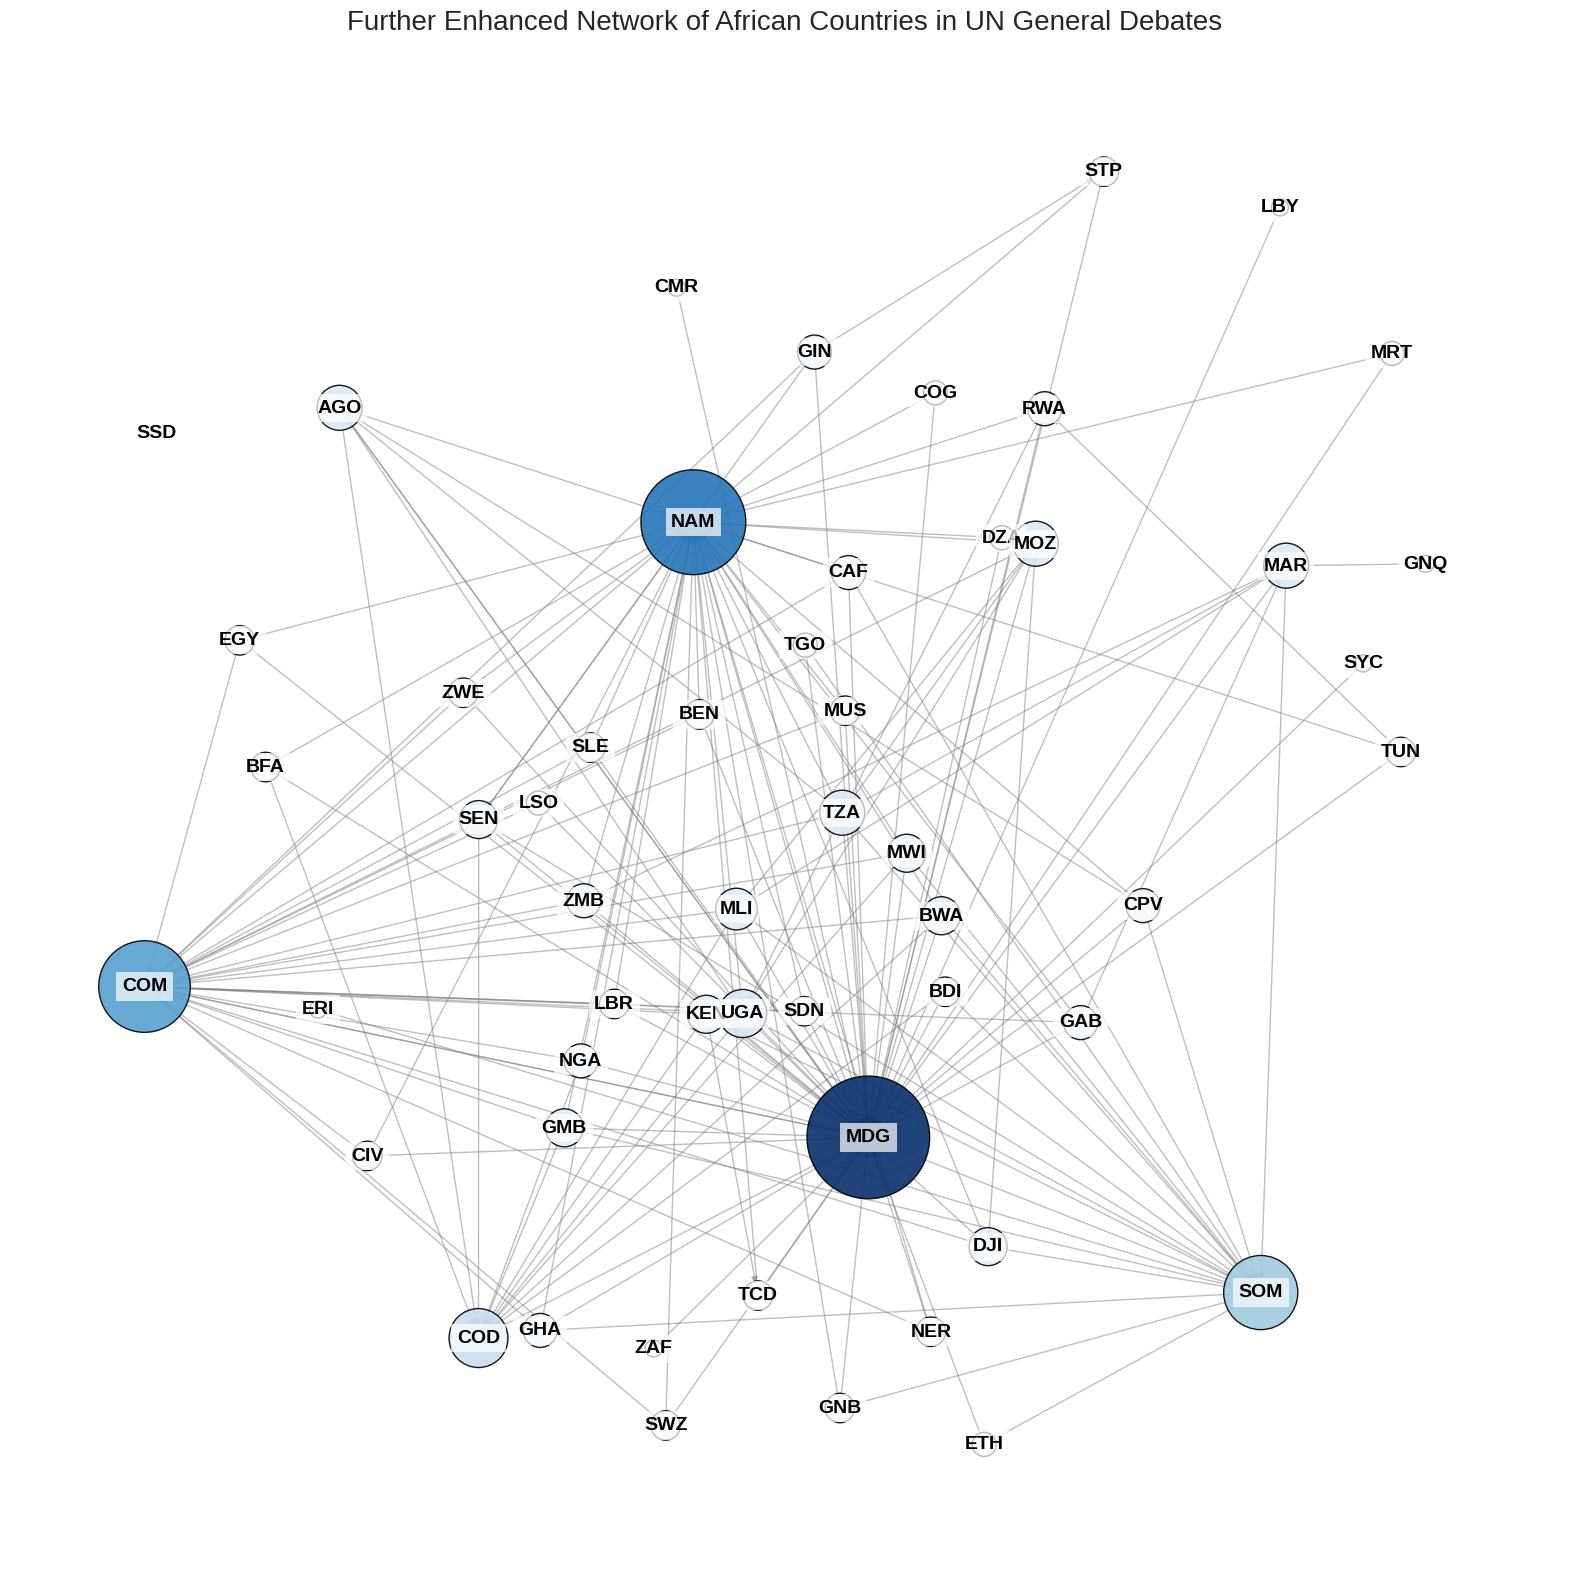

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# Path to save the plot
save_path = '/content/drive/MyDrive/SMWA Project/Africa/Graphs/network_plot.png'

# Create a directed graph
G = nx.DiGraph()

african_countries = [
    'DZA', 'AGO', 'BEN', 'BWA', 'BFA', 'BDI', 'CPV', 'CMR', 'CAF', 'TCD', 'COM', 'COD', 'COG',
    'DJI', 'EGY', 'GNQ', 'ERI', 'SWZ', 'ETH', 'GAB', 'GMB', 'GHA', 'GIN', 'GNB', 'CIV', 'KEN',
    'LSO', 'LBR', 'LBY', 'MDG', 'MWI', 'MLI', 'MRT', 'MUS', 'MAR', 'MOZ', 'NAM', 'NER', 'NGA',
    'RWA', 'STP', 'SEN', 'SYC', 'SLE', 'SOM', 'ZAF', 'SSD', 'SDN', 'TZA', 'TGO', 'TUN', 'UGA',
    'ZMB', 'ZWE'
]

# Filter the data for African countries
africa_data = processed_df[processed_df['country'].isin(african_countries)]

# Initialize nodes (countries)
for country in african_countries:
    G.add_node(country)

# Initialize edges based on mentions or co-occurrences
mentions = defaultdict(list)

for index, row in africa_data.iterrows():
    speech = row['text']
    country = row['country']
    for mentioned_country in african_countries:
        if mentioned_country in speech and mentioned_country != country:
            mentions[country].append(mentioned_country)

for country, mentioned_countries in mentions.items():
    for mentioned_country in mentioned_countries:
        if G.has_edge(country, mentioned_country):
            G[country][mentioned_country]['weight'] += 1
        else:
            G.add_edge(country, mentioned_country, weight=1)

# Adjust the layout to create more space between nodes
pos = nx.spring_layout(G, k=1.2)  # Further increase k to spread out the nodes

# Calculate node degrees
degrees = dict(G.degree())
max_degree = max(degrees.values())

# Draw the network with enhancements
plt.figure(figsize=(20, 20))
nx.draw_networkx_nodes(G, pos, node_size=[v * 150 for v in degrees.values()],
                       node_color=[v for v in degrees.values()], cmap=plt.cm.Blues, alpha=0.9, edgecolors='black')
edges = nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color='gray', alpha=0.5)

# Draw labels with increased size and background
nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold', labels={node: node for node in G.nodes()},
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

plt.title('Further Enhanced Network of African Countries in UN General Debates', fontsize=20)
plt.axis('off')

# Save the plot to the specified path
plt.savefig(save_path, format='png', dpi=300)
plt.show()
